In [1]:
#from scipy.signal import envelope, hilbert
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
import numpy.random as random
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import pywt

In [3]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()

In [3]:
#https://ataspinar.com/posts/a-guide-for-using-the-wavelet-transform-in-machine-learning/
## link for wavelet transform article

/home/kanwar/anaconda3/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


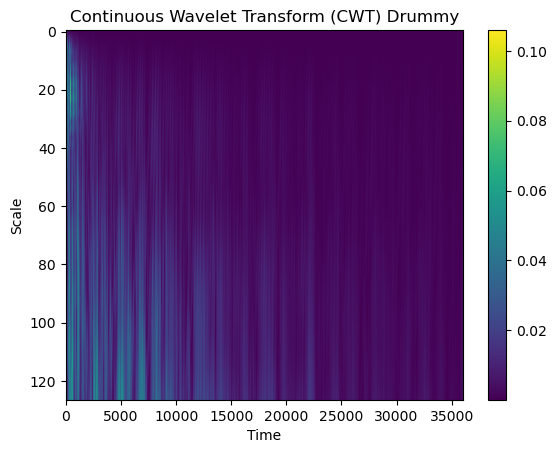

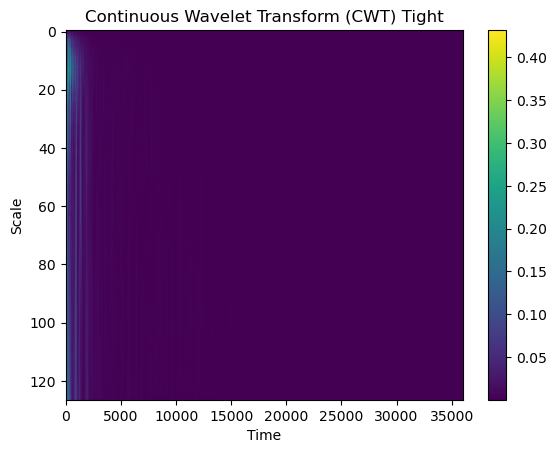

In [4]:
cwt = pywt.cwt(df.iloc[1, :-1].values, wavelet='cmor', scales=range(1,128))
cwt_1 = pywt.cwt(df.iloc[-1, :-1].values, wavelet='cmor', scales=range(1,128), axis=0)

#display cwt with matplotlib
import matplotlib.pyplot as plt
plt.imshow(np.abs(cwt[0]), aspect='auto')
plt.colorbar()
plt.title('Continuous Wavelet Transform (CWT) Drummy')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()

plt.imshow(np.abs(cwt_1[0]), aspect='auto')
plt.colorbar()
plt.title('Continuous Wavelet Transform (CWT) Tight')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()




In [10]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


data = Extract_Features(
    df_X = df_X,
    df_Y = df_Y,
    feature = "wave_transform",
    wavelet = "cmor",
    scales = 64,
    num_frames = 400
)

print(data.get_samples().shape)
print(data.get_labels().shape)

/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


KeyboardInterrupt: 

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveNetClassifier(nn.Module):
    def __init__(self, input_shape, num_classes=2):
        super(WaveNetClassifier, self).__init__()

        self.n_filters = 32
        self.filter_width = 3
        self.dilation_rates = [2 ** i for i in range(6)]  # [1, 2, 4, 8, 16, 32]
        in_channels = input_shape[1]  # 64

        self.conv_layers = nn.ModuleList([
            nn.Conv1d(
                in_channels=in_channels if i == 0 else self.n_filters,
                out_channels=self.n_filters,
                kernel_size=self.filter_width,
                dilation=d,
                padding='same'
            ) for i, d in enumerate(self.dilation_rates)
        ])

        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(self.n_filters) for _ in self.dilation_rates
        ])

        self.final_conv = nn.Conv1d(
            in_channels=self.n_filters,
            out_channels=16,
            kernel_size=3,
            padding='same'
        )
        self.final_bn = nn.BatchNorm1d(16)

        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        # x shape: (batch, 400, 64) → transpose to (batch, 64, 400)
        x = x.transpose(1, 2)  # (batch, in_channels=64, time=400)

        for conv, bn in zip(self.conv_layers, self.batch_norms):
            x = F.relu(bn(conv(x)))

        x = F.relu(self.final_bn(self.final_conv(x)))
        x = self.global_max_pool(x).squeeze(-1)  # shape: (batch, 16)

        x = self.fc(x)
        return F.softmax(x, dim=1)

import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 32

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = WaveNetClassifier(input_shape=(400, 64))

loops.train(model=model, model_path="./model_paths/cwt.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-2, optim="adam", epochs=20)

score = loops.test(model_path="./model_paths/cwt.pth", test_loader=test_loader, score = True)



[INFO] EPOCH: 1/20
Train loss: 0.622645, Train accuracy: 0.6727
[INFO] EPOCH: 2/20
Train loss: 0.574420, Train accuracy: 0.7243
[INFO] EPOCH: 3/20
Train loss: 0.546335, Train accuracy: 0.7523
[INFO] EPOCH: 4/20
Train loss: 0.533629, Train accuracy: 0.7777
[INFO] EPOCH: 5/20
Train loss: 0.527879, Train accuracy: 0.7777
[INFO] EPOCH: 6/20
Train loss: 0.511587, Train accuracy: 0.7987
[INFO] EPOCH: 7/20
Train loss: 0.508056, Train accuracy: 0.8017
[INFO] EPOCH: 8/20
Train loss: 0.501967, Train accuracy: 0.8080
[INFO] EPOCH: 9/20
Train loss: 0.503307, Train accuracy: 0.8087
[INFO] EPOCH: 10/20
Train loss: 0.490426, Train accuracy: 0.8217
[INFO] EPOCH: 11/20
Train loss: 0.486653, Train accuracy: 0.8240
[INFO] EPOCH: 12/20
Train loss: 0.494494, Train accuracy: 0.8157
[INFO] EPOCH: 13/20
Train loss: 0.486724, Train accuracy: 0.8280
[INFO] EPOCH: 14/20
Train loss: 0.476474, Train accuracy: 0.8410
[INFO] EPOCH: 15/20
Train loss: 0.474118, Train accuracy: 0.8390
[INFO] EPOCH: 16/20
Train loss: 0.

In [16]:
print("Test Accuracy: ",score) # = Test Accuracy:  0.6957928802588996

Test Accuracy:  0.6957928802588996


In [4]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


dwt_coeff = pywt.wavedec(df_X.values, wavelet = "db4", level=5) 
print(dwt_coeff[0].shape)  # Approximation coefficients

    

(3309, 1131)


In [5]:

data = Extract_Features(
    df_X = df_X,
    df_Y = df_Y,
    feature = "raw",
)

In [6]:
data.X_reduced = dwt_coeff[0]
print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 1131)
(3309,)


[INFO] EPOCH: 1/10
Train loss: 0.547597, Train accuracy: 0.6740
[INFO] EPOCH: 2/10
Train loss: 0.341153, Train accuracy: 0.8623
[INFO] EPOCH: 3/10
Train loss: 0.231461, Train accuracy: 0.9117
[INFO] EPOCH: 4/10
Train loss: 0.170962, Train accuracy: 0.9453
[INFO] EPOCH: 5/10
Train loss: 0.129557, Train accuracy: 0.9627
[INFO] EPOCH: 6/10
Train loss: 0.093300, Train accuracy: 0.9780
[INFO] EPOCH: 7/10
Train loss: 0.055147, Train accuracy: 0.9830
[INFO] EPOCH: 8/10
Train loss: 0.030046, Train accuracy: 0.9930
[INFO] EPOCH: 9/10
Train loss: 0.044815, Train accuracy: 0.9853
[INFO] EPOCH: 10/10
Train loss: 0.029885, Train accuracy: 0.9920
[INFO] Testing the model
Test accuracy: 0.9223


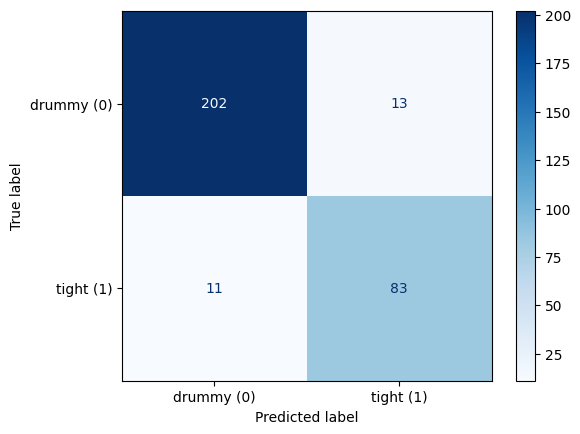


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.95      0.94      0.94       215
   tight (1)       0.86      0.88      0.87        94

    accuracy                           0.92       309
   macro avg       0.91      0.91      0.91       309
weighted avg       0.92      0.92      0.92       309



In [7]:
torch.manual_seed(42)

import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=256, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/dwt.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-3, optim="adam", epochs=10)

loops.test(model_path="./model_paths/dwt.pth", test_loader=test_loader, report=True)